<a href="https://colab.research.google.com/github/kyuwan25/26/blob/main/26_07_26_Robotics_Toolbox_for_Python_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Traceback (most recent call last):
  File "/usr/local/bin/pip3", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/main.py", line 78, in main
    command = create_command(cmd_name, isolated=("--isolated" in cmd_args))
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/__init__.py", line 114, in create_command
    module = importlib.import_module(module_path)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unloc

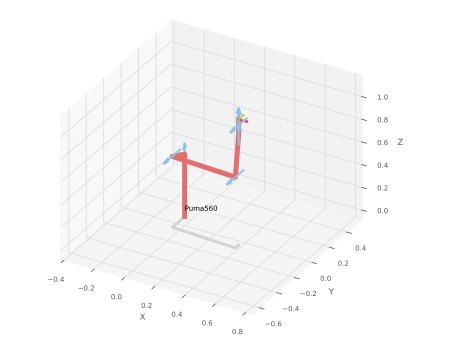

KeyboardInterrupt: Interrupted by user

In [10]:
#FK 정기구학
!pip install roboticstoolbox-python spatialmath-python
import roboticstoolbox as rtb
import numpy as np

# 3D Mesh 형상을 가진 URDF 모델 로드
Puma560 = rtb.models.URDF.Puma560()

pyplot = rtb.backends.PyPlot.PyPlot()
pyplot.launch(render_mode='notebook-inline')  # 핵심: Colab 셀 내부에 렌더링하도록 설정
pyplot.add(Puma560)

#각 관절별 회전부여
a =float(input("joint1(허리)의 회전: "))
b =float(input("joint2(어께)의 회전: "))
c =float(input("joint3(팔꿈치)의 회전: "))
d =float(input("joint4(손목)의 회전1: "))
e =float(input("joint5(손목굽힘)의 회전: "))
f =float(input("joint6(손목)의 회전2: "))

#.q부여
q = np.array([np.deg2rad(a), np.deg2rad(b), np.deg2rad(c),
             np.deg2rad(d), np.deg2rad(e), np.deg2rad(f)])
#마무리
Puma560.q=q
pyplot.step()
T= Puma560.fkine(q)

print("end-effector의 위치")
print(T.t) # T.t를 사용하여 위치 벡터를 가져옵니다.
print("end-effector의 자세")
print(T.R) # T.R을 사용하여 회전 행렬을 가져옵니다.

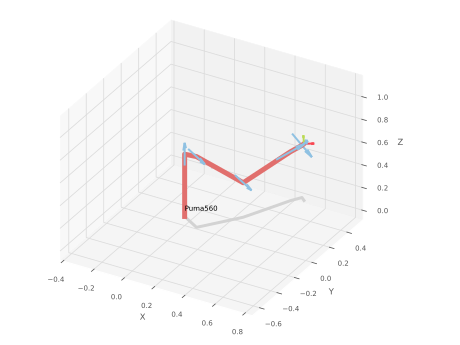

끝점의 X좌표: 0.5
끝점의 Y좌표: 0.5
끝점의 Z좌표: 0.5
끝점의 X축 회전: 30
끝점의 Y축 회전: 30
끝점의 Z축 회전: 30
목표 동차 변환행렬 (T_target):
   0.75     -0.433     0.5       0.5       
   0.6495    0.625    -0.433     0.5       
  -0.125     0.6495    0.75      0.5       
   0         0         0         1         

[계산 성공] 필요한 관절 각도(deg):
[ 58.44027527 -47.72219556 -21.1266852   41.48226451  80.17879381
 -31.83070336]


In [9]:
#IK 역기구학
import roboticstoolbox as rtb
import numpy as np
from spatialmath import SE3

# 3D Mesh 형상을 가진 URDF 모델 로드
Puma560 = rtb.models.URDF.Puma560()

pyplot = rtb.backends.PyPlot.PyPlot()
pyplot.launch(render_mode='notebook-inline')  # 핵심: Colab 셀 내부에 렌더링하도록 설정
pyplot.add(Puma560)

X_final =float(input("끝점의 X좌표: "))
Y_final =float(input("끝점의 Y좌표: "))
Z_final =float(input("끝점의 Z좌표: "))
theta_x =float(input("끝점의 X축 회전: "))
theta_y =float(input("끝점의 Y축 회전: "))
theta_z =float(input("끝점의 Z축 회전: "))

T_target = SE3(X_final, Y_final, Z_final) * SE3.Rx(np.deg2rad(theta_x)) * SE3.Ry(np.deg2rad(theta_y)) * SE3.Rz(np.deg2rad(theta_z))

print("목표 동차 변환행렬 (T_target):")
print(T_target)

sol = Puma560.ikine_LM(T_target)
Puma560.q = sol.q
pyplot.step()
# 3. 결과 확인
if sol.success:
    print("[계산 성공] 필요한 관절 각도(deg):")
    print(np.rad2deg(sol.q))# 3. 결과 확인
else :
    print("계산에 실패하였습니다.")